<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day02-tensors-and-a-first-class.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 2 — Programming in code: tensors, autograd, and a first class

The tensor/autograd sections below are reused directly from this course's own `notebooks/pytorch_bio_intro.ipynb` (only lightly trimmed) — no need to write this from scratch when it already existed and already uses a nice DNA-themed example. The exercises at the end are new, closing the loop with Day 1 and previewing Day 3.

# PyTorch for Biology: A Gentle, Code-First Intro

This notebook is for students with a biological background who want a fast, practical start with PyTorch. We'll use small, synthetic examples resembling gene expression and promoter detection so everything runs quickly on CPU.

In [1]:
# Section 1: Setup and installation checks
import torch, numpy as np, random, pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.5.1
CUDA available: False
Using device: cpu


/home/arnee/miniforge3/envs/ekman-teaching/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /opt/conda/conda-bld/pytorch_1729647429097/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Tensors: creation, shapes, and dtypes
We'll start with DNA-encoded toy data (A,T,G,C mapped to 0–3) to show tensor creation, shapes, and dtypes.

In [2]:
# Small DNA example: 4 samples, 8 bases each encoded as ints 0-3
bases = np.array([
    [0,1,2,3,0,1,2,3],
    [3,3,2,2,1,1,0,0],
    [1,0,1,0,2,2,3,3],
    [2,2,1,1,0,0,3,3],
], dtype=np.int64)

tensor_from_np = torch.tensor(bases)                 # infers dtype/int64
float_tensor = torch.tensor(bases, dtype=torch.float32)
zeros = torch.zeros((2,3), dtype=torch.float32)
ones  = torch.ones((2,3), dtype=torch.float32)
rand  = torch.rand((2,3), dtype=torch.float32)

print("tensor_from_np:", tensor_from_np.shape, tensor_from_np.dtype)
print("float_tensor :", float_tensor.shape, float_tensor.dtype)
print("zeros shape   :", zeros.shape, "ones shape:", ones.shape, "rand shape:", rand.shape)

tensor_from_np: torch.Size([4, 8]) torch.int64
float_tensor : torch.Size([4, 8]) torch.float32
zeros shape   : torch.Size([2, 3]) ones shape: torch.Size([2, 3]) rand shape: torch.Size([2, 3])


## 3. Basic tensor operations (indexing, slicing, reshaping)
Think of rows as samples and columns as genes/features. We'll slice, reshape, and concatenate.

In [3]:
data = float_tensor  # from earlier cell

first_two_samples = data[:2, :]          # slicing
first_four_features = data[:, :4]
reshaped = data.view(2, 2, 8)             # reshape into (batch, chunk, features)
concat = torch.cat([data, data], dim=0)   # stack samples

print("First two samples:\n", first_two_samples)
print("First four features of all samples:\n", first_four_features)
print("Reshaped (2,2,8):", reshaped.shape)
print("Concatenated shape:", concat.shape)

# Elementwise operations
mean_per_feature = data.mean(dim=0)
std_per_feature  = data.std(dim=0)
print("Feature means:", mean_per_feature)
print("Feature stds :", std_per_feature)

First two samples:
 tensor([[0., 1., 2., 3., 0., 1., 2., 3.],
        [3., 3., 2., 2., 1., 1., 0., 0.]])
First four features of all samples:
 tensor([[0., 1., 2., 3.],
        [3., 3., 2., 2.],
        [1., 0., 1., 0.],
        [2., 2., 1., 1.]])
Reshaped (2,2,8): torch.Size([2, 2, 8])
Concatenated shape: torch.Size([8, 8])
Feature means: tensor([1.5000, 1.5000, 1.5000, 1.5000, 0.7500, 1.0000, 2.0000, 2.2500])
Feature stds : tensor([1.2910, 1.2910, 0.5774, 1.2910, 0.9574, 0.8165, 1.4142, 1.5000])


## 4. Autograd: gradients on simple functions
PyTorch tracks operations when `requires_grad=True`. Let's compute a simple mean-square and get gradients.

In [4]:
x = torch.linspace(-2, 2, steps=5, requires_grad=True)
y = (x**2).mean()  # simple function
print("y:", y.item())

y.backward()       # compute dy/dx
print("dy/dx:", x.grad)

y: 2.0
dy/dx: tensor([-0.8000, -0.4000,  0.0000,  0.4000,  0.8000])


## 5. A first class: representing a biological sequence

Day 1's OOP section talked about bundling data and behaviour together. Here's a minimal, real example: a class representing a DNA sequence, with a method to compute GC content — a preview of Day 3, where sequences like this come from real databases.

In [5]:
class DnaSequence:
    """A minimal class bundling a DNA sequence with a couple of useful methods."""

    def __init__(self, name, bases):
        self.name = name
        self.bases = bases.upper()

    def __len__(self):
        return len(self.bases)

    def gc_content(self):
        gc = sum(1 for b in self.bases if b in "GC")
        return gc / len(self.bases)

    def __repr__(self):
        return f"DnaSequence({self.name!r}, length={len(self)}, GC={self.gc_content():.2f})"


seq1 = DnaSequence("toy_seq_1", "ATGCGATACGGCTAGC")
seq2 = DnaSequence("toy_seq_2", "TTTTAAATTTAAATTT")

print(seq1)
print(seq2)
print("seq1 GC content:", seq1.gc_content())
print("seq2 GC content:", seq2.gc_content())

DnaSequence('toy_seq_1', length=16, GC=0.56)
DnaSequence('toy_seq_2', length=16, GC=0.00)
seq1 GC content: 0.5625
seq2 GC content: 0.0


## 7. Biopython: the real `DnaSequence`

The class above is a useful exercise, but nobody writes their own sequence
class from scratch in practice — **Biopython** already provides one, with
far more functionality (translation, file parsing, database access, and
much more), battle-tested and used throughout real bioinformatics
pipelines.

In [6]:
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

bio_seq = Seq("ATGCGATACGGCTAG")

print("sequence:           ", bio_seq)
print("length:              ", len(bio_seq))
print("GC fraction:         ", gc_fraction(bio_seq))
print("reverse complement:  ", bio_seq.reverse_complement())
print("translated (codons):", bio_seq.translate())

sequence:            ATGCGATACGGCTAG
length:               15
GC fraction:          0.5333333333333333
reverse complement:   CTAGCCGTATCGCAT
translated (codons): MRYG*


## 8. NumPy and pandas: arrays and tables

**NumPy** is the array library underneath almost everything in the
scientific Python stack, including PyTorch tensors and pandas itself —
you've already been using NumPy-style thinking since section 2. **pandas**
builds a labeled, tabular data structure (the `DataFrame`) on top of NumPy
arrays — the natural format for, say, a table of many sequences and their
properties, rather than one sequence at a time.

Below, a synthetic set of 50 toy "genes" is generated directly with NumPy
(lengths, and a GC content that increases with length plus random noise —
not biologically meaningful, just something with a real relationship to
recover later), then wrapped in a pandas `DataFrame`.

In [7]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=0)

n_genes = 50
lengths = rng.integers(100, 1000, size=n_genes)
noise = rng.normal(0, 0.03, size=n_genes)
gc_content = np.clip(0.3 + 0.0003 * lengths + noise, 0, 1)

genes = pd.DataFrame({
    "name": [f"gene_{i}" for i in range(n_genes)],
    "length": lengths,
    "gc_content": gc_content,
})

print(genes.head())
print()
print(genes.describe())

     name  length  gc_content
0  gene_0     865    0.562320
1  gene_1     673    0.479595
2  gene_2     560    0.440348
3  gene_3     342    0.388868
4  gene_4     377    0.419706

           length  gc_content
count   50.000000   50.000000
mean   512.520000    0.460031
std    273.843635    0.089423
min    102.000000    0.265995
25%    257.250000    0.385970
50%    566.500000    0.462944
75%    703.000000    0.532858
max    973.000000    0.636703


## 9. Matplotlib and seaborn: plotting

**Matplotlib** is the base plotting library; **seaborn** builds a
higher-level, statistics-oriented interface on top of it that works
directly with pandas DataFrames. The same relationship (length vs. GC
content) is easier to *see* than to read off a table.

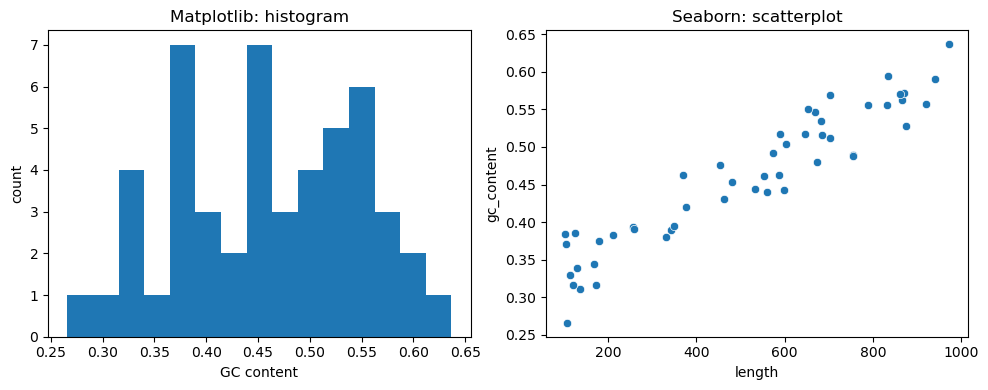

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(genes["gc_content"], bins=15)
axes[0].set_xlabel("GC content")
axes[0].set_ylabel("count")
axes[0].set_title("Matplotlib: histogram")

sns.scatterplot(data=genes, x="length", y="gc_content", ax=axes[1])
axes[1].set_title("Seaborn: scatterplot")

fig.tight_layout()
plt.show()

## 10. SciPy: a quick statistical test

**SciPy** extends NumPy with ready-made scientific routines — statistics,
optimization, signal processing, and more. Here, `scipy.stats` checks
whether the length/GC-content relationship visible in the plot above is
actually statistically significant, using a Pearson correlation test.

In [9]:
from scipy import stats

r, p_value = stats.pearsonr(genes["length"], genes["gc_content"])
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")

Pearson r = 0.944, p = 9.78e-25


## 11. scikit-learn: linear regression

Day 6 builds a linear model "by hand" with raw tensors and gradient
descent, precisely to see the mechanics. In practice, for a plain linear
regression like this one, you would normally reach for **scikit-learn**'s
ready-made implementation instead — it fits the same kind of model in one
line, without writing a training loop yourself.

In [10]:
from sklearn.linear_model import LinearRegression

X = genes[["length"]]  # scikit-learn expects a 2D array of features
y = genes["gc_content"]

model = LinearRegression()
model.fit(X, y)

print("slope (per base):", model.coef_[0])
print("intercept:        ", model.intercept_)
print("R^2 on training data:", model.score(X, y))
print("(ground truth used to generate the data: slope=0.0003, intercept=0.3)")

slope (per base): 0.0003082228065033034
intercept:         0.3020608547966878
R^2 on training data: 0.8909068712829619
(ground truth used to generate the data: slope=0.0003, intercept=0.3)


## 6. Closing the loop with Day 1

Day 1's practice problems were done entirely by hand. Here they are again, this time in code — confirm you get the same answers.

In [11]:
import torch

# Day 1, practice problem 1: (2, -1, 3) . (1, 4, 0)
a = torch.tensor([2., -1., 3.])
b = torch.tensor([1., 4., 0.])
print("dot product:", torch.dot(a, b).item(), " (Day 1 answer: -2)")

# Day 1, practice problem 2: gradient of f(x0, x1) = 3*x0**2 + 2*x0*x1 at (1, 2)
x0 = torch.tensor(1., requires_grad=True)
x1 = torch.tensor(2., requires_grad=True)
f = 3*x0**2 + 2*x0*x1
f.backward()
print("gradient:", (x0.grad.item(), x1.grad.item()), " (Day 1 answer: (10, 2))")

dot product: -2.0  (Day 1 answer: -2)
gradient: (10.0, 2.0)  (Day 1 answer: (10, 2))


## Try it yourself

Add a method to `DnaSequence` that returns the reverse complement. (Hint: complement each base with a dictionary lookup — `{'A':'T','T':'A','G':'C','C':'G'}` — then reverse the result.)